In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Question 7

In **Q5**, the 3-node Gauss quadrature on an arbitrary interval $[a, b]$ was derived.

In [2]:
def gauss_3_node(f, a, b):
    h = b - a
    p2 = (a + b) / 2
    w = np.sqrt(3) / (2 * np.sqrt(5))
    return (h / 18) * (
        5 * f(p2 - w * h)
        + 8 * f(p2)
        + 5 * f(p2 + w * h)
    )

### Q7 (a)

Do a convergence study in the interval size $h = b - a$ to find the error scaling of this quadrature in $(b - a)$ both graphically and by computing the experimental order of convergence (EOC) for a suitable number of experiments and spacings for the function $f(x) = \sin x$ on the interval $[1, 1 + h]$.

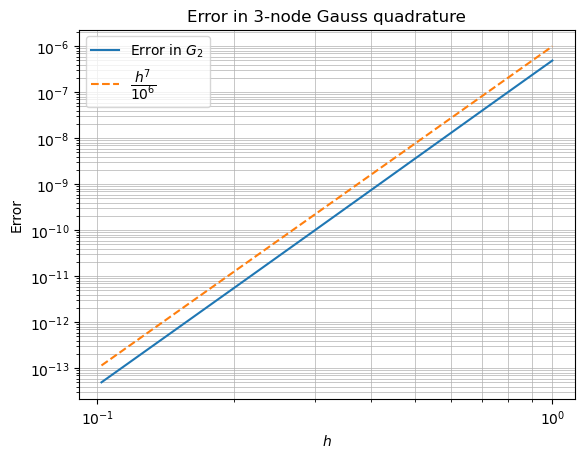

In [3]:
def plot_gauss_3_node_error():
    h = np.linspace(0, 1, 50)[5:]

    exact = np.array(list(map(
        lambda h_: -np.cos(1 + h_) + np.cos(1), h
    )))
    gauss = np.array(list(map(
        lambda h_: gauss_3_node(np.sin, 1, 1 + h_), h
    )))
    
    plt.loglog(h, np.abs(exact - gauss), label="Error in $G_2$")
    plt.loglog(h, h**7 / 10**6, label=r"$\dfrac{h^7}{10^6}$", linestyle="dashed")
    
    plt.grid(True, which='both', linestyle='-', linewidth=0.5)
    
    plt.title(r"Error in 3-node Gauss quadrature")
    plt.legend()
    plt.xlabel("$h$")
    plt.ylabel("Error")

    plt.show()
    plt.clf()
    plt.close()


plot_gauss_3_node_error()

In [4]:
print("h\tGauss EOC")
print("-----------------")

hs = np.linspace(0, 1, 11)[1:]

for i in range(1, len(hs)):
    h = hs[i]
    gauss = gauss_3_node(np.sin, 1, 1 + h)
    true = -np.cos(1 + h) + np.cos(1)
    error = gauss - true

    prev_h = hs[i - 1]
    prev_gauss = gauss_3_node(np.sin, 1, 1 + prev_h)
    prev_true = -np.cos(1 + prev_h) + np.cos(1)
    prev_error = prev_gauss - prev_true

    eoc = np.log(prev_error / error) / np.log(2)
    
    print(f"{h:.1f}\t{eoc:.4g}")

h	Gauss EOC
-----------------
0.2	-7.041
0.3	-4.129
0.4	-2.935
0.5	-2.278
0.6	-1.862
0.7	-1.573
0.8	-1.361
0.9	-1.198
1.0	-1.069


### Q7 (b)

Compute on some reasonable sized interval the integral of polynomials of different order to demonstrate that your implementation has the expected degree of precision.

In [5]:
print("All integrals computed over [-2, 2]\n")
print("p_n(x)\t\t\tI(x)\tG_2(x)")
print("---------------------------------------")

print(f"3x\t\t\t0\t{gauss_3_node(lambda x: 3*x, -2, 2)}")
print(f"-2x^2 + 3x - 1\t\t{-44/3:.3f}\t{gauss_3_node(lambda x: -2*x**2 + 3*x - 1, -2, 2):.3f}")
print(f"x^3 - x^2 + 2x + 1\t{-4/3:.3f}\t{gauss_3_node(lambda x: x**3 - x**2 + 1*x + 1, -2, 2):.3f}")
print(f"x^4 + 3x^2 - 2\t\t{104/5:.3f}\t{gauss_3_node(lambda x: x**4 + 3*x**2 - 2, -2, 2):.3f}")
print(f"x^5 + x^3 - x^2\t\t{-16/3:.3f}\t{gauss_3_node(lambda x: x**5 + x**3 - x**2, -2, 2):.3f}")
print(f"x^6 + 2x^4 - x^3 + 1\t{2316/35:.3f}\t{gauss_3_node(lambda x: x**6 + 2*x**4 - x**3 + 1, -2, 2):.3f}")

All integrals computed over [-2, 2]

p_n(x)			I(x)	G_2(x)
---------------------------------------
3x			0	0.0
-2x^2 + 3x - 1		-14.667	-14.667
x^3 - x^2 + 2x + 1	-1.333	-1.333
x^4 + 3x^2 - 2		20.800	20.800
x^5 + x^3 - x^2		-5.333	-5.333
x^6 + 2x^4 - x^3 + 1	66.171	60.320


# Question 8

Write two functions, `composite_trapezoidal(f, a, b, n)` and `composite_simpson(f, a, b, n)` which implement the composite trapezoidal and composite Cavalieri–Simpson rules respectively, where $f : [a, b] \to \mathbb{R}$ is a function and $n$ is the number of equally sized subintervals in $[a, b]$.

In [6]:
def composite_trapezoidal(f, a, b, n):
    h = (b - a) / n
    x = np.linspace(a, b, n + 1)
    mid_x = x[1:-1]
    
    return h * (0.5 * f(x[0]) + np.sum(f(mid_x)) + 0.5 * f(x[-1])) 


def composite_simpson(f, a, b, n):
    h = (b - a) / (2 * n)
    x = np.linspace(a, b, 2 * n + 1)
    
    mid_x = x[1:-1]
    x_odd = mid_x[::2]
    x_even = mid_x[1::2]
    
    return (h / 3) * (f(x[0]) + 4 * np.sum(f(x_odd)) + 2 * np.sum(f(x_even)) + f(x[-1]))

### Q8 (a)

Do a convergence study for the function $f(x) = \cosh x$ on the interval $[0, 1]$ by performing multiple experiments for $n = 2^k$ with $k \in \{0, \dotsc, 10\}$. Then plot, in a log-log plot, the observed quadrature error against $h = \frac 1n$ (which is a variable proportional to the node spacings), and comparing against lines $\tilde h^\gamma$ for appropriately chosen $\gamma$ to find the scaling of the errors of the two methods.

In [7]:
print("n\t\tTrapezoidal error\tSimpson error")
print("-----------------------------------------------------")
exact = np.sinh(1) - np.sinh(0)

for k in range(11):
    n = 2**k
    trap_error = np.abs(exact - composite_trapezoidal(np.cosh, 0, 1, n))
    simp_error = np.abs(exact - composite_simpson(np.cosh, 0, 1, n))
    print(f"2^{{{k}}}\t\t{trap_error:.5g}\t\t{simp_error:.5g}")

n		Trapezoidal error	Simpson error
-----------------------------------------------------
2^{0}		0.096339		0.00039622
2^{1}		0.024382		2.5315e-05
2^{2}		0.0061145		1.591e-06
2^{3}		0.0015298		9.9577e-08
2^{4}		0.00038253		6.2257e-09
2^{5}		9.5637e-05		3.8914e-10
2^{6}		2.3909e-05		2.4322e-11
2^{7}		5.9774e-06		1.5199e-12
2^{8}		1.4943e-06		9.5035e-14
2^{9}		3.7359e-07		5.9952e-15
2^{10}		9.3397e-08		4.4409e-16


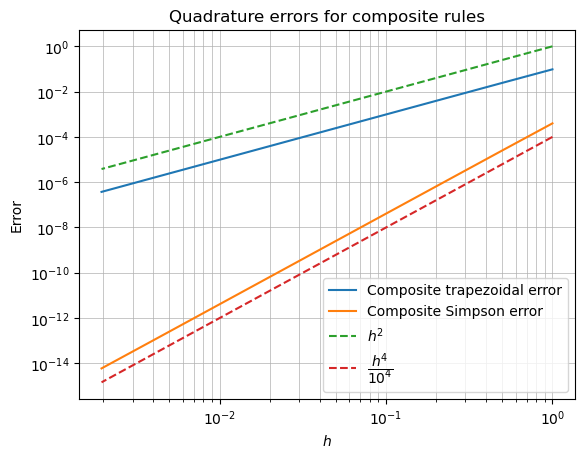

In [8]:
def plot_trap_simp_error():
    k = np.arange(10)
    n = 2**k
    h = 1 / n
    exact = np.sinh(1) - np.sinh(0)
    
    trap = np.array(list(map(
        lambda n_: composite_trapezoidal(np.cosh, 0, 1, n_), n
    )))
    simp = np.array(list(map(
        lambda n_: composite_simpson(np.cosh, 0, 1, n_), n
    )))
    
    plt.loglog(h, np.abs(exact - trap), label=f"Composite trapezoidal error")
    plt.loglog(h, np.abs(exact - simp), label=f"Composite Simpson error")
    
    plt.loglog(h, h**2, label="$h^2$", linestyle="dashed")
    plt.loglog(h, h**4 / 10**4, label=r"$\dfrac{h^4}{10^4}$", linestyle="dashed")

    plt.grid(True, which='both', linestyle='-', linewidth=0.5)
    
    plt.title(r"Quadrature errors for composite rules")
    plt.legend()
    plt.xlabel("$h$")
    plt.ylabel("Error")

    plt.show()
    plt.clf()
    plt.close()


plot_trap_simp_error()

The line for the composite trapezoidal error has the same slope as $h^2$ and the line for the composite Simpson error has the same slope as $h^4$, as expected.

### Q8 (b)

Compute, with an error less than $10^{-5}$, the integral $$\large \int_2^3 \frac{1}{\ln x} \, \mathrm{d} x$$ via the composite trapezoidal rule. Remember to comment on why your error must definitely be lower than the demanded bound.

The composite trapezoidal rule has absolute quadrature error bounded by $$|E_{1,n}(f)| \le \frac{1}{12} h^2 (b-a) \|f''\|_\infty,$$ provided that $f \in C^2([a, b], \mathbb{R})$, where $h = \dfrac{b-a}{n}$. To make $|E_{1, n}(f)| < 10^{-5}$, we require $$\begin{align}
\frac{1}{12} \frac{(b - a)^3}{n^2} \|f''\|_\infty &< 10^{-5} \\[0.5ex]
\frac{10^5 (3 - 2)^3 \|f''\|_\infty}{12} &< n^2 \\[0.5ex]
\frac{10^5 \|f''\|_\infty}{12} &< n^2
\end{align}$$ where of course $f(x) = \dfrac{1}{\ln x}$, so $$f'(x) = -\frac{1}{x (\ln x)^2}$$ and $$f''(x) = \frac{2 + \ln x}{x^2 (\ln x)^3}.$$

This is decreasing for $x > 1$ and we only care about $x \in [2, 3]$, so in this case, $$\|f''\|_\infty = f''(2) = \frac{2 + \ln 2}{4 (\ln 2)^3}.$$
Therefore we just need to choose $$n > \sqrt{\frac{10^5 (2 + \ln 2)}{48 (\ln 2)^3}} \approx 129.799,$$ so we just choose $n = 130$ to guarantee that the error is less than $10^{-5}$. Of course, there may be some $n$ smaller than $130$ which also gives a satisfactorily small error.

In [9]:
print(composite_trapezoidal(lambda x: 1 / np.log(x), 2, 3, 130))

1.1184285842757609


# Question 9

Consider the initial value problem $$\large y'(t) = \alpha \cos(t) y(t), \quad y(0) = 1,$$ for $\alpha \in \mathbb{R}$ and $t \in [0, 2]$.

### Q9 (a)

Implement the forward Euler method and plot its result $u_n$ against the exact results $y(t)$ for $N = 10$ time steps, for the values $\alpha \in \{-0.8, -0.1, 0.1, 0.8\}$ into a single figure.

In [10]:
def forward_euler(f, y_0, t_start, t_end, n_steps):
    """Return an approximate solution of an IVP using the forward Euler method.

    `f` is a function $f(t, y)$ representing $y'$.
    `y_0` is `y(t_start)`.
    `t_start` is the starting time value.
    `t_end` is the ending time value.
    `n_steps` is the number of steps. The returned array will have `n_steps + 1` elements.
    """
    h = (t_end - t_start) / n_steps
    rv = [y_0]

    for i in range(n_steps):
        u_i = rv[-1]
        t_i = t_start + i * h
        u_next = u_i + h * f(t_i, u_i)

        rv.append(u_next)

    return np.array(rv)

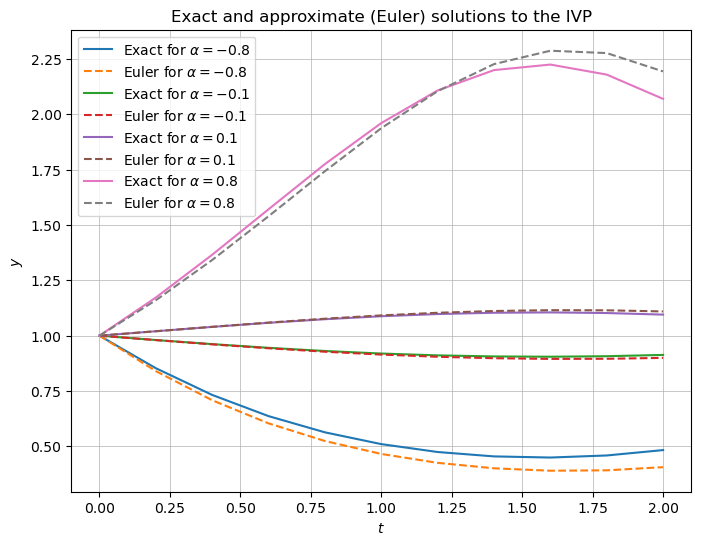

In [11]:
def plot_forward_euler():
    def f(alpha):
        def f_inner(t, y):
            return alpha * np.cos(t) * y
        return f_inner

    plt.rcParams["figure.figsize"] = (8, 6)

    N = 10
    x = np.linspace(0, 2, N + 1)

    for alpha in (-0.8, -0.1, 0.1, 0.8):
        exact = np.exp(alpha * np.sin(x))
        euler = forward_euler(f(alpha), 1, 0, 2, N)
        
        plt.plot(x, exact, label=f"Exact for $\\alpha = {alpha}$")
        plt.plot(x, euler, label=f"Euler for $\\alpha = {alpha}$", linestyle="dashed")

    plt.grid(True, which='both', linestyle='-', linewidth=0.5)
    
    plt.title(r"Exact and approximate (Euler) solutions to the IVP")
    plt.legend()
    plt.xlabel("$t$")
    plt.ylabel("$y$")

    plt.show()
    plt.clf()
    plt.close()
    
    plt.rcParams["figure.figsize"] = plt.rcParamsDefault["figure.figsize"]


plot_forward_euler()

### Q9 (b)

Similarly, implement the Heun method, and again plot its results $u_i$ against the exact result for $N = 10$ time steps, for the values $\alpha \in \{-0.8, -0.1, 0.1, 0.8\}$. Comment on the comparison between the two.

In [12]:
def heun(f, y_0, t_start, t_end, n_steps):
    """Return an approximate solution of an IVP using the Heun method.

    `f` is a function $f(t, y)$ representing $y'$.
    `y_0` is `y(t_start)`.
    `t_start` is the starting time value.
    `t_end` is the ending time value.
    `n_steps` is the number of steps. The returned array will have `n_steps + 1` elements.
    """
    h = (t_end - t_start) / n_steps
    rv = [y_0]

    for i in range(n_steps):
        u_i = rv[-1]
        t_i = t_start + i * h
        t_i_plus_1 = t_start + (i + 1) * h
        f_i = f(t_i, u_i)
        u_next = u_i + (h / 2) * (f_i + f(t_i_plus_1, u_i + h * f_i))

        rv.append(u_next)

    return np.array(rv)

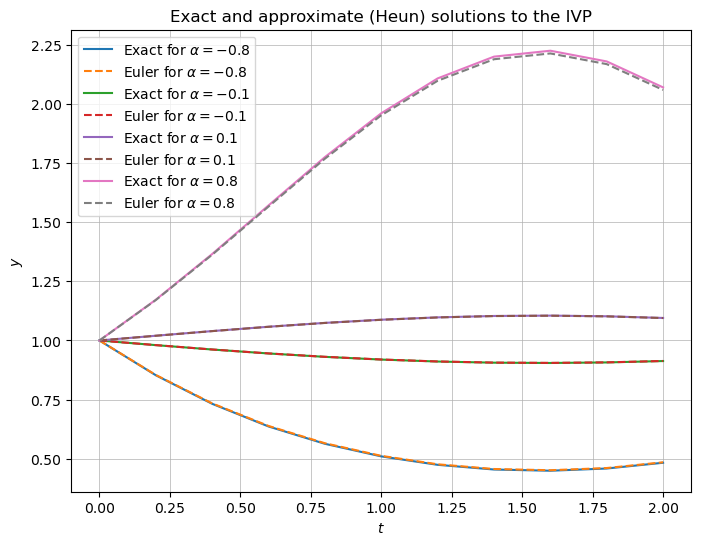

In [13]:
def plot_heun():
    def f(alpha):
        def f_inner(t, y):
            return alpha * np.cos(t) * y
        return f_inner

    plt.rcParams["figure.figsize"] = (8, 6)

    N = 10
    x = np.linspace(0, 2, N + 1)

    for alpha in (-0.8, -0.1, 0.1, 0.8):
        exact = np.exp(alpha * np.sin(x))
        euler = heun(f(alpha), 1, 0, 2, N)
        
        plt.plot(x, exact, label=f"Exact for $\\alpha = {alpha}$")
        plt.plot(x, euler, label=f"Euler for $\\alpha = {alpha}$", linestyle="dashed")

    plt.grid(True, which='both', linestyle='-', linewidth=0.5)
    
    plt.title(r"Exact and approximate (Heun) solutions to the IVP")
    plt.legend()
    plt.xlabel("$t$")
    plt.ylabel("$y$")

    plt.show()
    plt.clf()
    plt.close()
    
    plt.rcParams["figure.figsize"] = plt.rcParamsDefault["figure.figsize"]


plot_heun()

The forward Euler method is quite close to the exact values, but the Heun method is much better, making it the superior choice in this case.